## Working with Time Series:

In [139]:
import pandas as pd

df = pd.read_csv('lemonade_sales.csv')

In [140]:
df.drop(columns='Index', inplace=True)
df.head()

,Date,Customer_Names,Lemonades
0,2025-01-01,Ali,15
1,2025-01-02,Hira,3
2,2025-01-03,Daniyal,5
3,2025-01-04,Bilal,7
4,2025-01-05,Noor,5


### DateTime Index:

In [141]:
# Convert the "Date" column into a standard datetime format so pandas can recognize and work with dates correctly
df['Date'] = pd.to_datetime(df['Date'])

# Set the "Date" column as the DataFrame index and display the first 5 rows
df.set_index('Date', inplace=True)
df.head()

,Customer_Names,Lemonades
Date,,
2025-01-01,Ali,15
2025-01-02,Hira,3
2025-01-03,Daniyal,5
2025-01-04,Bilal,7
2025-01-05,Noor,5


### Converting Strings to Dates:

In [142]:
# Convert the string date '1/2/20' into pandas datetime format
# Pandas automatically interprets and standardizes the date value
pd.to_datetime('1/2/20')

Timestamp('2020-01-02 00:00:00')

### Resampling:

In [143]:
# Resample data weekly and sum only numeric columns
df.resample('W').sum(numeric_only=True)

# Resample data at month end and sum only numeric columns
df.resample('ME').sum(numeric_only=True)

# Resample data at month start and sum only numeric columns
df.resample('MS').sum(numeric_only=True)

# Resample data at year end and sum only numeric columns
df.resample('YE').sum(numeric_only=True)

# Resample data at year start and sum only numeric columns
df.resample('YS').sum(numeric_only=True)

,Lemonades
Date,
2025-01-01,809


### Shifting/Lagging:

In [144]:
# Shift the "Lemonades" column down by 1 row to get the previous row's value
# The first row becomes NaN because there is no previous value
df['Previous_Lemonades'] = df['Lemonades'].shift(1)

df.head(8)

,Customer_Names,Lemonades,Previous_Lemonades
Date,,,
2025-01-01,Ali,15,NaN
2025-01-02,Hira,3,15.0
2025-01-03,Daniyal,5,3.0
2025-01-04,Bilal,7,5.0
2025-01-05,Noor,5,7.0
2025-01-06,Laiba,7,5.0
2025-01-07,Taha,12,7.0
2025-01-08,Daniyal,1,12.0


### Rolling Calculations:

In [145]:
# Calculate the rolling average of "Lemonades" over a window of 3 rows
# Each row shows the average of the current row and the previous 2 rows
# First 2 rows become NaN because there are not enough previous values to complete the 3-row window
df['Rolling_Average'] = df['Lemonades'].rolling(3).mean()

df.head(6)

,Customer_Names,Lemonades,Previous_Lemonades,Rolling_Average
Date,,,,
2025-01-01,Ali,15,NaN,NaN
2025-01-02,Hira,3,15.0,NaN
2025-01-03,Daniyal,5,3.0,7.666667
2025-01-04,Bilal,7,5.0,5.000000
2025-01-05,Noor,5,7.0,5.666667
2025-01-06,Laiba,7,5.0,6.333333


### Data Visualization:

### Basic Plotting:

<Axes: title={'center': 'Lemonade Sales Over Time'}, xlabel='Date'>

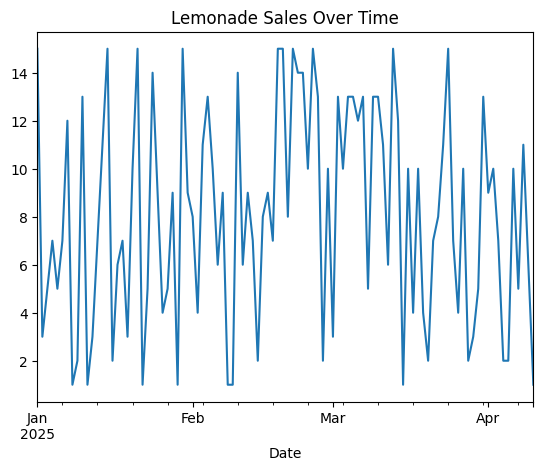

In [146]:
# We are using Pandas to plot the "Lemonades" column
# Pandas provides the .plot() function, but it does NOT draw the graph itself
# Internally, Pandas sends the data to Matplotlib, which is responsible for actually creating and displaying the graph
# The title parameter adds a heading to the graph for better understanding

df['Lemonades'].plot(title='Lemonade Sales Over Time')

### Different kind of Plots:

<Axes: title={'center': 'Lemonade Sales Over Time'}, xlabel='Date'>

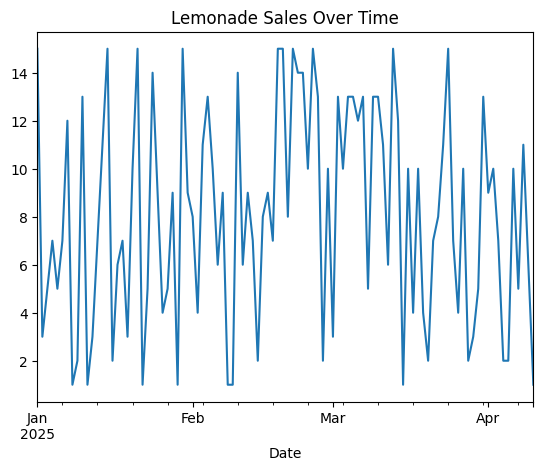

In [173]:
# Line plot (default graph type) of Lemonades
# Shows how values change across the index (time/order of rows)
df['Lemonades'].plot(kind='line', title='Lemonade Sales Over Time')

<Axes: xlabel='Date'>

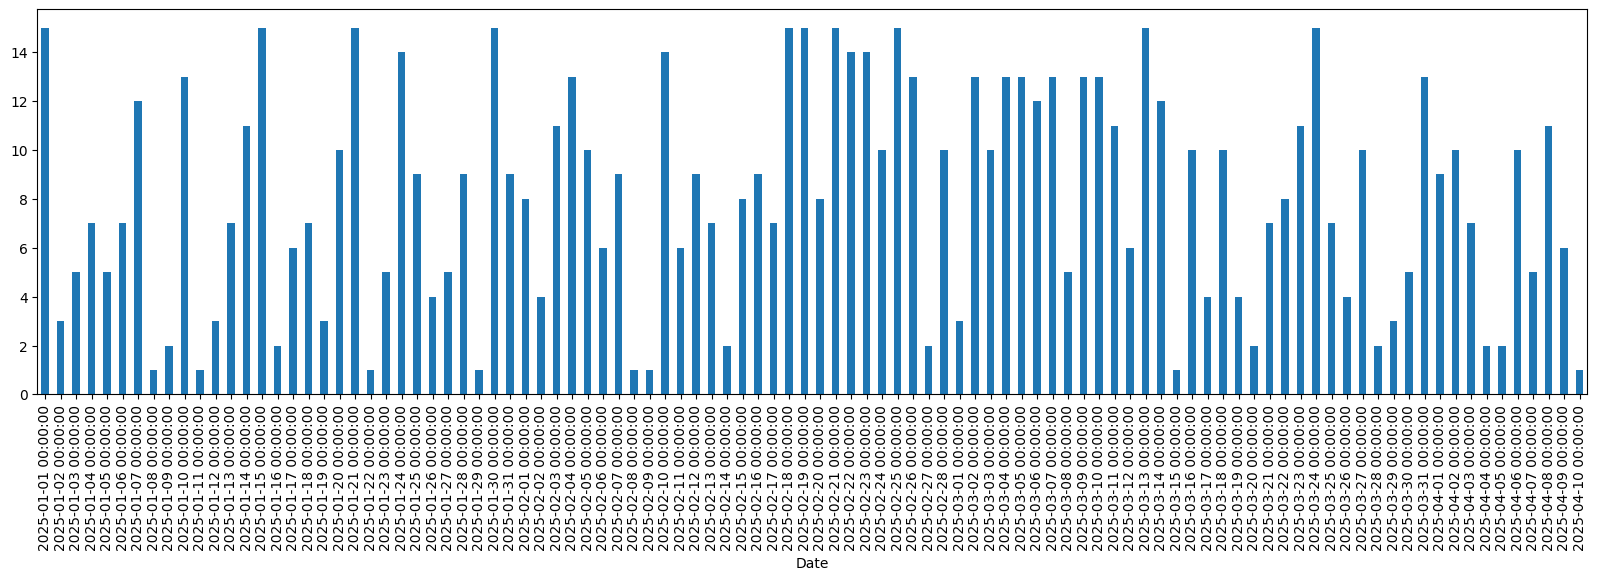

In [ ]:
# First attempt (commented out) failed because plotting a datetime index directly as a bar chart
# caused Pandas to expect a fixed frequency (freq metadata), which was missing or inconsistent
# df['Lemonades'].plot(kind='bar')

# Second approach:
# Resample the data daily ('D') to ensure a proper fixed frequency time series
# Then sum the values for each day to make the data clean and evenly spaced
# Select only the "Lemonades" column after aggregation
# Finally plot as a bar chart with a larger figure size for better visibility
df.resample('D').sum()['Lemonades'].plot(kind='bar', figsize=(20,5))

<Axes: ylabel='Date'>

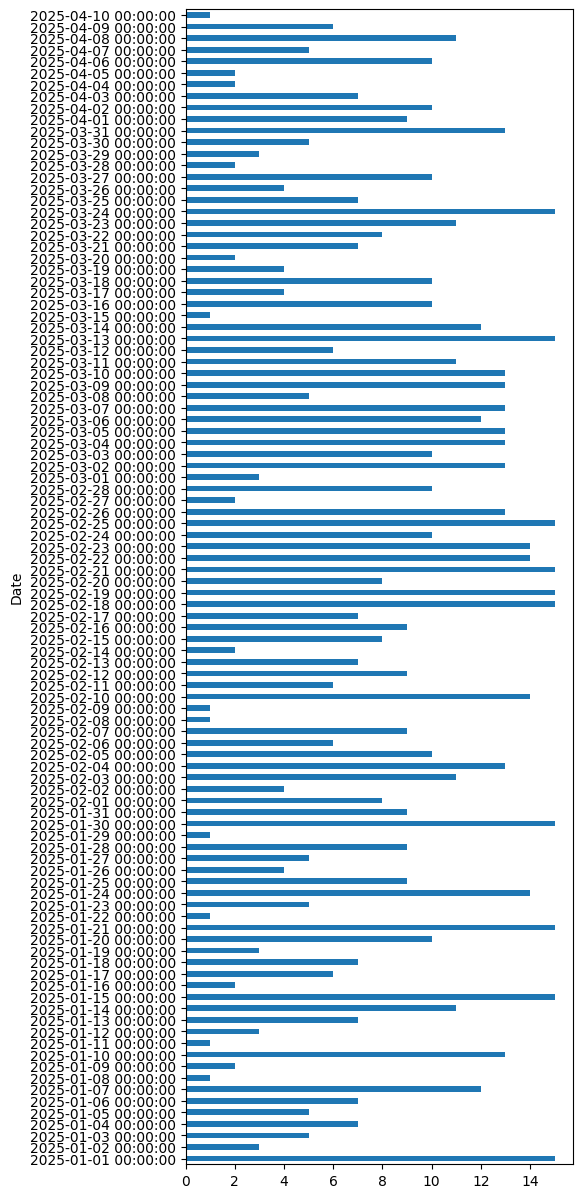

In [150]:
# Plot a horizontal bar chart (barh) to visualize daily sales
# figsize controls the width and height of the graph for better readability

df.resample('D').sum()['Lemonades'].plot(kind='barh', figsize=(5,15))

<Axes: ylabel='Frequency'>

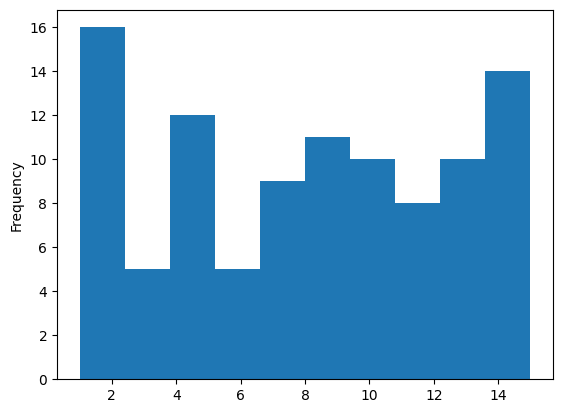

In [ ]:
# Plot a histogram of the "Lemonades" column
# This shows the distribution of values (how many times each range of values occurs)
# It does NOT use the index or date — only the numerical values in the column are used

df['Lemonades'].plot(kind='hist')

<Axes: >

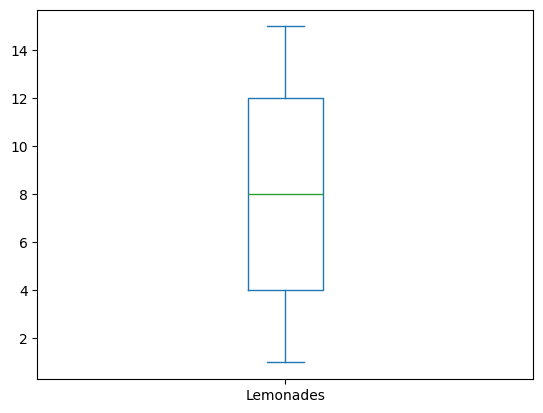

In [172]:
# Plot a box plot for the "Lemonades" column
# This shows the statistical summary of the data including:
# - Median (middle value)
# - Quartiles (25%, 50%, 75%)
# - Outliers (extreme values)
# It helps to understand data spread and detect unusual values

df['Lemonades'].plot(kind='box')

<Axes: xlabel='Lemonades', ylabel='Lemonades'>

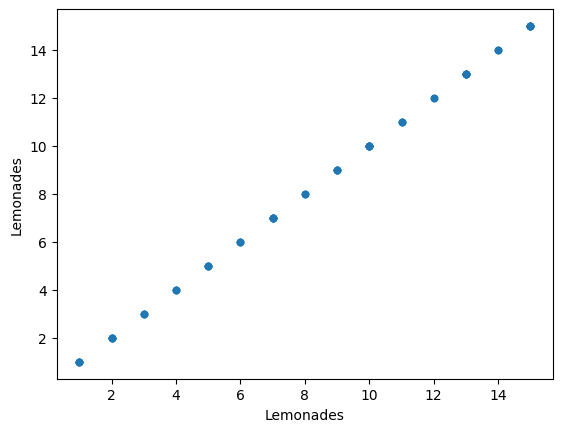

In [159]:
# Create a scatter plot using the same column "Lemonades" for both x and y axes
# This plots each value against itself, so all points lie on a diagonal line (y = x)

df.plot(kind='scatter', x='Lemonades', y='Lemonades')

<Axes: title={'center': 'Lemonade Sales Over Time'}, xlabel='Date'>

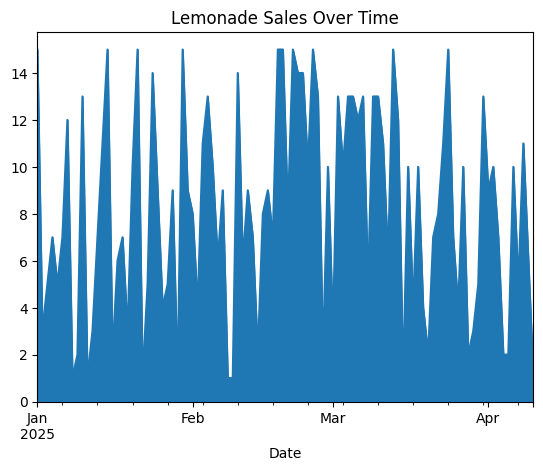

In [161]:
df['Lemonades'].plot(kind='area', title='Lemonade Sales Over Time')

<Axes: >

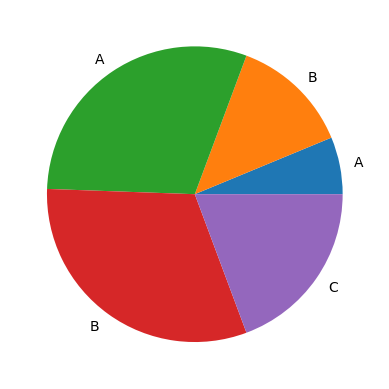

In [174]:
s1 = pd.Series(['A', 'B', 'A', 'B', 'C'])
s2 = pd.Series([11, 23, 53, 55, 34])

# Create DataFrame
data = pd.DataFrame({
    'Name': s1,
    'Lemonades': s2
})

data.set_index('Name')['Lemonades'].plot(kind='pie')